# Setup

In [5]:
%load_ext autoreload
%autoreload 2

import data
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
pd.set_option("display.max_columns", 40)

print(data.__file__)   # should end in /data.py — if it prints None, data.py isn't beside the notebook

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
/Users/eddy/Documents/Actuary MSc/m_SMM284 Applied Machine Learning/a_assessment_group09-due-15Jul/flood-claims-notebook-v1/data.py


In [4]:
import os, sys
print("cwd:", os.getcwd())
print("data* files here:", [f for f in os.listdir() if f.startswith("data")])

sys.modules.pop("data", None)      # drop the cached 'data = folder' from earlier
import data
print("data.__file__:", data.__file__)   # want .../data.py, NOT None

cwd: /Users/eddy/Documents/Actuary MSc/m_SMM284 Applied Machine Learning/a_assessment_group09-due-15Jul/flood-claims-notebook-v1
data* files here: ['data', 'data.py']
data.__file__: /Users/eddy/Documents/Actuary MSc/m_SMM284 Applied Machine Learning/a_assessment_group09-due-15Jul/flood-claims-notebook-v1/data.py


In [6]:
if "df" not in globals():
    # downloads the parquet on the very first run, cached after
    df = data.load_raw()                
print(f"{df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

2,721,780 rows x 30 columns


,amountPaidOnBuildingClaim,ratedFloodZone,elevationDifference,baseFloodElevation,lowestFloorElevation,lowestAdjacentGrade,elevatedBuildingIndicator,basementEnclosureCrawlspaceType,obstructionType,occupancyType,numberOfFloorsInTheInsuredBuilding,buildingDescriptionCode,condominiumCoverageTypeCode,postFIRMConstructionIndicator,originalConstructionDate,primaryResidenceIndicator,rentalPropertyIndicator,totalBuildingInsuranceCoverage,totalContentsInsuranceCoverage,buildingDeductibleCode,crsClassificationCode,elevationCertificateIndicator,state,countyCode,yearOfLoss,dateOfLoss,latitude,longitude,buildingReplacementCost,buildingPropertyValue
0,7243.04,A07,None,None,None,None,False,NaN,10.0,1.0,1.0,NaN,N,False,1970-07-01,False,False,59700.0,8800.0,1,NaN,NaN,NJ,34025,1992,1992-12-11,40.4,-74.0,0.0,24400.0
1,39008.35,AE,6.0,7.4,0.0,0.0,True,NaN,15.0,11.0,2.0,1.0,N,False,1982-01-01,False,False,250000.0,21000.0,F,NaN,NaN,FL,12037,2018,2018-10-10,29.7,-84.9,299144.0,257264.0
2,None,A17,None,None,None,None,False,2.0,10.0,1.0,2.0,NaN,N,False,1959-07-01,False,False,176000.0,50000.0,1,NaN,NaN,PA,42091,1996,1996-12-16,40.1,-75.4,NaN,NaN
3,3559.00,AE,None,None,None,None,False,NaN,10.0,1.0,1.0,NaN,N,False,1492-10-12,True,False,18300.0,0.0,0,NaN,2,MS,28109,2001,2001-06-14,30.5,-89.7,129000.0,124000.0
4,15784.20,C,None,None,None,None,False,NaN,10.0,1.0,1.0,NaN,N,False,1492-10-12,False,False,33000.0,10000.0,NaN,NaN,NaN,TX,48039,1979,1979-07-26,29.4,-95.2,0.0,53300.0


In [7]:
schema = data.get_field_schema()        # name / type / description / key / nullable
schema.head()

,name,type,description,primaryKey,isNullable
0,asOfDate,datetime,The effective date of the data in the file. In...,False,True
1,amountPaidOnBuildingClaim,"decimal(12,2)",Dollar amount paid on the building claim. In s...,False,True
2,amountPaidOnContentsClaim,"decimal(12,2)",Dollar amount paid on the contents claim. In s...,False,True
3,amountPaidOnIncreasedCostOfComplianceClaim,"decimal(12,2)",ICC coverage is one of several flood insurance...,False,True
4,netBuildingPaymentAmount,"decimal(12,2)",Net building payment amount made to insured in...,False,True


In [8]:
display(df.dtypes)
df.isna().mean().sort_values(ascending=False).head(20)   # sparsest columns first

amountPaidOnBuildingClaim              object
ratedFloodZone                            str
elevationDifference                    object
baseFloodElevation                     object
lowestFloorElevation                   object
lowestAdjacentGrade                    object
elevatedBuildingIndicator                bool
basementEnclosureCrawlspaceType       float64
obstructionType                       float64
occupancyType                         float64
numberOfFloorsInTheInsuredBuilding    float64
buildingDescriptionCode               float64
condominiumCoverageTypeCode               str
postFIRMConstructionIndicator            bool
originalConstructionDate               object
primaryResidenceIndicator                bool
rentalPropertyIndicator                  bool
totalBuildingInsuranceCoverage        float64
totalContentsInsuranceCoverage        float64
buildingDeductibleCode                    str
crsClassificationCode                 float64
elevationCertificateIndicator     

crsClassificationCode                 0.949849
lowestAdjacentGrade                   0.810814
elevationCertificateIndicator         0.779866
lowestFloorElevation                  0.763696
baseFloodElevation                    0.756969
elevationDifference                   0.729864
basementEnclosureCrawlspaceType       0.697886
buildingDescriptionCode               0.639162
obstructionType                       0.444430
buildingReplacementCost               0.219006
buildingPropertyValue                 0.218964
amountPaidOnBuildingClaim             0.208081
buildingDeductibleCode                0.098972
ratedFloodZone                        0.051081
countyCode                            0.022942
longitude                             0.015225
latitude                              0.015225
condominiumCoverageTypeCode           0.013760
numberOfFloorsInTheInsuredBuilding    0.006337
originalConstructionDate              0.000730
dtype: float64

count     2155429
unique    1357994
top          0.00
freq       150348
Name: amountPaidOnBuildingClaim, dtype: object
zero payouts: 0.055
negative payouts: 86


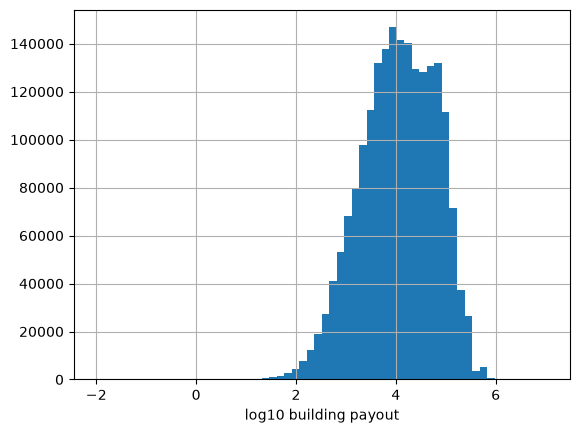

In [9]:
print(df[data.TARGET].describe())
print(
    "zero payouts:", (df[data.TARGET] == 0).mean().round(3)
)  # denied / no building payment
print("negative payouts:", (df[data.TARGET] < 0).sum())  # re-issued cheques
pos = df[df[data.TARGET] > 0][data.TARGET]
np.log10(pos).hist(bins=60)
plt.xlabel("log10 building payout")
plt.show()

In [10]:
for col in ["elevationDifference", "baseFloodElevation"]:
    print(col, "== 9999 sentinel:", (df[col] == 9999).mean().round(3))
print(df["occupancyType"].value_counts().head(12))   # 1-digit legacy vs 2-digit Risk Rating 2.0
print(df["ratedFloodZone"].value_counts().head(12))

elevationDifference == 9999 sentinel: 0.0
baseFloodElevation == 9999 sentinel: 0.0
occupancyType
1.0     1793554
11.0     414893
4.0      170158
2.0      130077
3.0       79118
18.0      36948
15.0      24434
6.0       23703
12.0      19640
16.0      10671
14.0       9443
13.0       8207
Name: count, dtype: int64
ratedFloodZone
AE     939766
X      406706
A      201560
C      164158
B      115181
A04     51876
A01     51408
A05     48604
VE      47935
A06     47105
A08     45756
A07     43730
Name: count, dtype: int64
